# Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# Loading data

In [ ]:
df_features = pd.read_csv("../dataset/o_shank.csv")
df_distances = pd.read_csv("../dataset/distances.csv")
df_distances = df_distances[:df_features.shape[0]]
X = df_features.values
y = df_distances.iloc[:, 0].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X, y)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# SVR

      C  epsilon       mse        r2  execution_time  best_model
0   0.1     0.01  0.025160  0.751408        2.696304       False
1   0.1     0.10  0.027303  0.730232        1.079138       False
2   0.1     0.02  0.025202  0.750988        2.281804       False
3   1.0     0.01  0.014698  0.854777        4.969593       False
4   1.0     0.10  0.018160  0.820572        1.134407       False
5   1.0     0.02  0.014916  0.852622        3.556349       False
6  10.0     0.01  0.014222  0.859476       21.605238       False
7  10.0     0.10  0.017102  0.831024        1.090504       False
8  10.0     0.02  0.014144  0.860252       12.375178        True


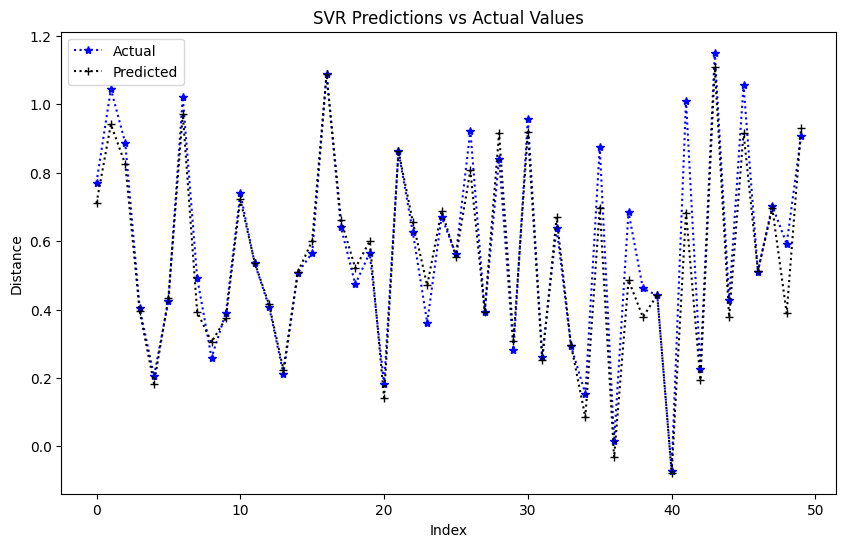

In [ ]:
C_values = (0.1, 1.0, 10.0)
epsilon_values = (0.01, 0.1, 0.02)
results = []

best_y_pred = None
best_mse = float('inf')
best_r2 = float('-inf')
best_C = None
best_epsilon = None
best_runtime = None

for C in C_values:
    for epsilon in epsilon_values:
        svr = SVR(kernel='rbf', epsilon=epsilon, C=C)
        start_time = time.time()
        svr.fit(X_train, y_train)
        y_pred = svr.predict(X_test)
        end_time = time.time()
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        if mse < best_mse and r2 > best_r2:
            best_mse = mse
            best_r2 = r2
            best_y_pred = y_pred
            best_C = C
            best_epsilon = epsilon
            best_runtime = end_time - start_time

        results.append({
            "C": C,
            "epsilon": epsilon,
            "mse": mse,
            "r2": r2,
            "execution_time": end_time - start_time,
        })

df_results = pd.DataFrame(results)
best_index = df_results[(df_results["C"] == best_C) & (df_results["epsilon"] == best_epsilon)].index[0]
df_results["best_model"] = False
df_results.loc[best_index, "best_model"] = True

print(df_results)

df_results.to_csv("../results/svr_v3.1.csv", index=False)

indices = list(range(len(y_test[:50])))
plt.figure(figsize=(10, 6))
plt.plot(indices, y_test[:50], 'b:*', label='Actual')
plt.plot(indices, best_y_pred[:50], 'k:+', label='Predicted')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.title('SVR Predictions vs Actual Values')
plt.legend()
plt.show()
